In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
patient_df = pd.read_csv('Patient_Info.csv')
outcome_df = pd.read_csv('Treatment_Outcome.csv')
tumor_df = pd.read_csv('Tumor_Clinical_Data.csv')

In [3]:
# Check for empty cell
print(patient_df[patient_df.isna().any(axis=1)])
print(outcome_df[outcome_df.isna().any(axis=1)])
print(tumor_df[tumor_df.isna().any(axis=1)])

Empty DataFrame
Columns: [Patient_ID, Age, Gender]
Index: []
Empty DataFrame
Columns: [Patient_ID, Treatment_Type, Surgery_Performed, Chemotherapy, Radiation_Therapy, Survival_Months, Tumor_Progression, Recurrence, Outcome_Status, Early_Detection_Label, Treatment_Response]
Index: []
Empty DataFrame
Columns: [Patient_ID, Tumor_Type, Tumor_Size_mm, Tumor_Location, Tumor_Grade, Headache, Seizures, Vision_Problems, Nausea, Cognitive_Changes, MRI_Intensity_Mean, MRI_Texture_Feature, Edema_Presence, Contrast_Enhancement, Family_History, Smoking_Status, Radiation_Exposure, Genetic_Risk]
Index: []


In [4]:
patient_df.head()

,Patient_ID,Age,Gender
0,1,61,Male
1,2,24,Female
2,3,70,Male
3,4,30,Female
4,5,33,Female


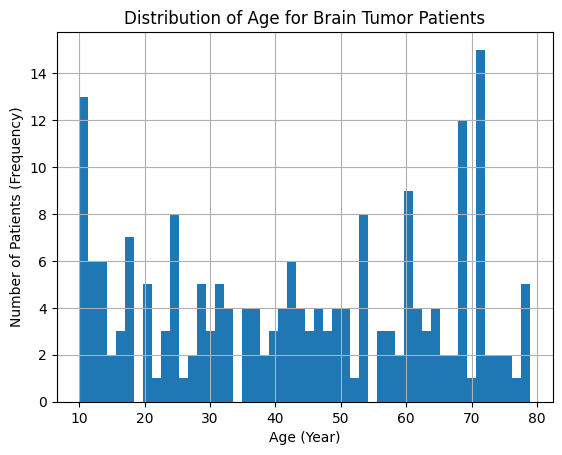

In [6]:
# patient database
patient_df["Age"].hist(bins = 50)
plt.title('Distribution of Age for Brain Tumor Patients')
plt.xlabel('Age (Year)')
plt.ylabel('Number of Patients (Frequency)')
plt.show()

In [7]:
# Check for significant diffrent between the age dist between two gender
patient_df["Gender"].value_counts()
males = patient_df[patient_df["Gender"] == "Male"]["Age"]
females = patient_df[patient_df["Gender"] == "Female"]["Age"]

_, tp_value = stats.ttest_ind(males, females, equal_var=False)
_, up_value = stats.mannwhitneyu(males, females, alternative='two-sided')
print(tp_value)
print(up_value)

0.4417544921745472
0.39386091827718506


In [8]:
# Drop treatment type because 3 next columns already cover it in more detail. it seeem like patients does not usually go trough one single treatment
outcome_df = outcome_df.drop(columns="Treatment_Type")
outcome_df.columns

Index(['Patient_ID', 'Surgery_Performed', 'Chemotherapy', 'Radiation_Therapy',
       'Survival_Months', 'Tumor_Progression', 'Recurrence', 'Outcome_Status',
       'Early_Detection_Label', 'Treatment_Response'],
      dtype='object')

In [9]:
outcome_df["Treatment_Response"].value_counts()

,count
Treatment_Response,
Poor,74
Moderate,65
Good,61


In [10]:
# change categorical into ordinal number --> find correlation
outcome_map = {"Recovered" : 1, "Stable" : 0, "Critical" : -1}
outcome_df["Outcome_Status"] = outcome_df["Outcome_Status"].map(outcome_map)
print(outcome_df["Outcome_Status"].value_counts())

print("\n")
treatment_response_map = {"Good" : 1, "Moderate" : 0, "Poor" : -1}
outcome_df["Treatment_Response"] = outcome_df["Treatment_Response"].map(treatment_response_map)
print(outcome_df["Treatment_Response"].value_counts())

print("\n")


Outcome_Status
 1    68
 0    68
-1    64
Name: count, dtype: int64


Treatment_Response
-1    74
 0    65
 1    61
Name: count, dtype: int64




-0.05818113745613268


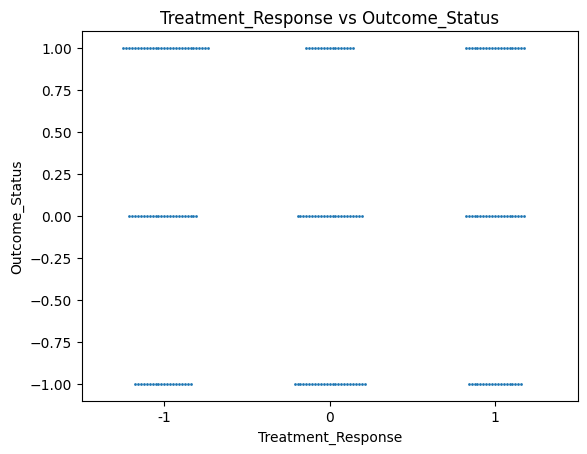

In [11]:
# corr between treatment respone vs outcome status
print(outcome_df["Treatment_Response"].corr(outcome_df["Outcome_Status"]))

sns.swarmplot(data=outcome_df, x='Treatment_Response', y='Outcome_Status', size=2)
plt.title('Treatment_Response vs Outcome_Status')
plt.show()


Survival_Months
98     7
114    5
64     4
89     4
72     4
      ..
115    1
66     1
54     1
100    1
75     1
Name: count, Length: 95, dtype: int64


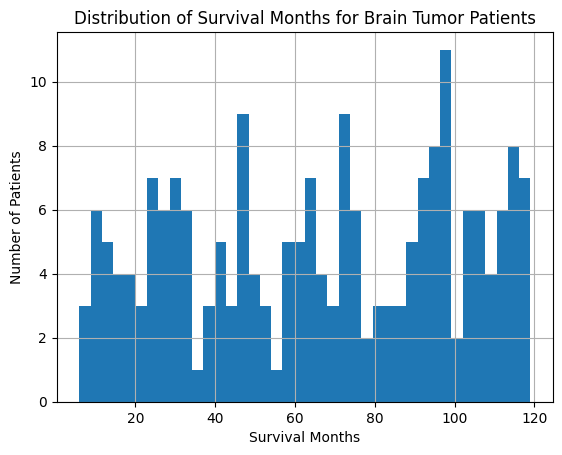

In [12]:
# outcome database
print(outcome_df["Survival_Months"].value_counts())
outcome_df["Survival_Months"].hist(bins = 40)
plt.title('Distribution of Survival Months for Brain Tumor Patients')
plt.xlabel('Survival Months')
plt.ylabel('Number of Patients')
plt.show()

In [13]:
# Does tumor progression associate survival month - No
tumor_progression = outcome_df[outcome_df["Tumor_Progression"] == 1]["Survival_Months"]
no_tumor_progression = outcome_df[outcome_df["Tumor_Progression"] == 0]["Survival_Months"]

_, tp_value = stats.ttest_ind(tumor_progression, no_tumor_progression, equal_var=False)
print(tp_value)

# Does tumor progression associate with treatment response - no
twtable = pd.crosstab(outcome_df["Tumor_Progression"], outcome_df["Treatment_Response"])
_, p_chi, _, _ = stats.chi2_contingency(twtable)
print(p_chi)

# Does tumor progression associate with Outcome_Status - no
twtable = pd.crosstab(outcome_df["Tumor_Progression"], outcome_df["Outcome_Status"])
_, p_chi, _, _ = stats.chi2_contingency(twtable)
print(p_chi)


0.5542065607947383
0.9803764103117732
0.5958758328272002


In [14]:
# Does Recurrence affect survival month - No --> almost exactly the same dist
recur = outcome_df[outcome_df["Recurrence"] == 1]["Survival_Months"]
no_recur = outcome_df[outcome_df["Recurrence"] == 0]["Survival_Months"]

_, tp_value = stats.ttest_ind(recur, no_recur, equal_var=False)
print(tp_value)

# Does Recurrence associate with treatment response - no --> same dist
twtable = pd.crosstab(outcome_df["Recurrence"], outcome_df["Treatment_Response"])
_, p_chi, _, _ = stats.chi2_contingency(twtable)
print(p_chi)

# Does Recurrence associate with Outcome_Status. kinda small, but not enough, so still NO
twtable = pd.crosstab(outcome_df["Recurrence"], outcome_df["Outcome_Status"])
_, p_chi, _, _ = stats.chi2_contingency(twtable)
print(p_chi)


0.9981164574412815
0.5045919417458176
0.08646933947860198


In [15]:
# Does Early_Detection_Label affect survival month - no
early = outcome_df[outcome_df["Early_Detection_Label"] == 1]["Survival_Months"]
no_early = outcome_df[outcome_df["Early_Detection_Label"] == 0]["Survival_Months"]

_, tp_value = stats.ttest_ind(early, no_early, equal_var=False)
print(tp_value)

# Does Early_Detection_Label associate with treatment response - no
twtable = pd.crosstab(outcome_df["Early_Detection_Label"], outcome_df["Treatment_Response"])
_, p_chi, _, _ = stats.chi2_contingency(twtable)
print(p_chi)

# Does Early_Detection_Label associate with Outcome_Status - no
twtable = pd.crosstab(outcome_df["Early_Detection_Label"], outcome_df["Outcome_Status"])
_, p_chi, _, _ = stats.chi2_contingency(twtable)
print(p_chi)


0.29648916582448015
0.1372882598049326
0.3751639468835335


In [16]:
print(tumor_df.groupby("Tumor_Type")["Tumor_Size_mm"].mean())
# dist of tumor size according to tumor type is not sign different
typ1 = tumor_df[tumor_df["Tumor_Type"] == "Glioma"]["Tumor_Size_mm"]
typ2 = tumor_df[tumor_df["Tumor_Type"] == "Meningioma"]["Tumor_Size_mm"]
typ3 = tumor_df[tumor_df["Tumor_Type"] == "Pituitary"]["Tumor_Size_mm"]

stat_lev, p_lev = stats.levene(typ1, typ2, typ3)
print(p_lev)

f_stat, p_anova = stats.f_oneway(typ1, typ2, typ3)

print(f"F-Statistic: {f_stat:.2f}")
print(f"ANOVA P-value: {p_anova:.4f}")

Tumor_Type
Glioma        31.629114
Meningioma    33.317500
Pituitary     33.260702
Name: Tumor_Size_mm, dtype: float64
0.903604340246199
F-Statistic: 0.28
ANOVA P-value: 0.7589


In [17]:
tumor_type_map = {"I" : 1, "II" : 2, "III" : 3, "IV" : 4}
tumor_df["Tumor_Grade"] = tumor_df["Tumor_Grade"].map(tumor_type_map)

0.032729426218099385


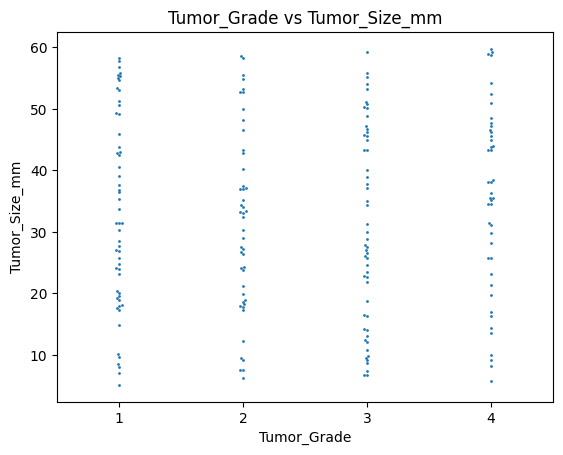

In [18]:
print(tumor_df["Tumor_Grade"].corr(tumor_df["Tumor_Size_mm"]))
sns.swarmplot(data=tumor_df, x='Tumor_Grade', y='Tumor_Size_mm', size=2)
plt.title('Tumor_Grade vs Tumor_Size_mm')
plt.show()

In [19]:
# join all tables
dfmerge = patient_df.merge(outcome_df, on="Patient_ID", how ="inner").merge(tumor_df, on="Patient_ID", how = "inner")
dfmerge.head()
dfmerge.columns

smoking_map = {"Yes" : 1, "No" :0}
dfmerge["Smoking_Status"] = dfmerge["Smoking_Status"].map(smoking_map)

0.3488872485825434


<Axes: >

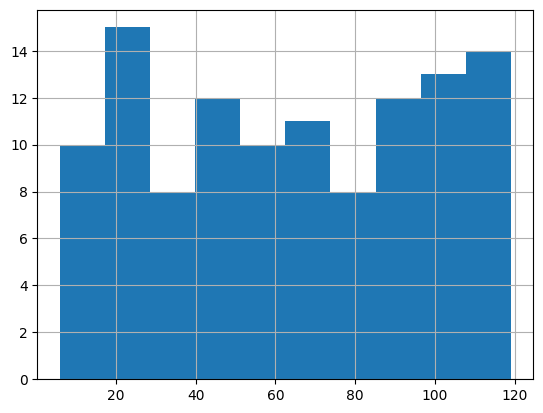

In [33]:
# age vs survival months
less40 = dfmerge[dfmerge["Age"] <= 40]["Survival_Months"]
more40 = dfmerge[dfmerge["Age"] > 40]["Survival_Months"]
_, tp_value = stats.ttest_ind(less40, more40, equal_var=False)
print(tp_value)
more40.hist()

Text(0.5, 1.0, 'Treatments vs Symptoms')

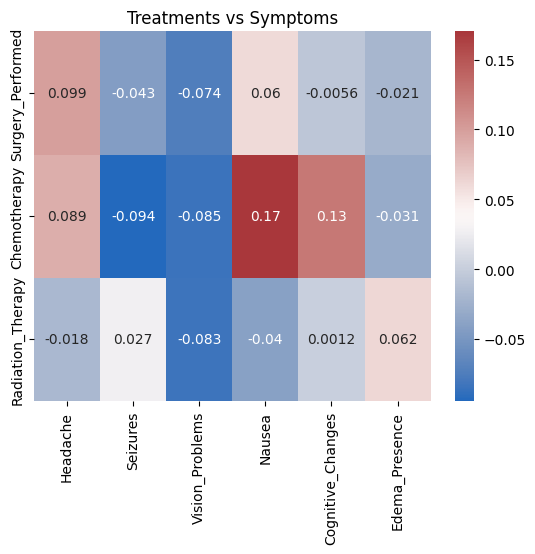

In [35]:
# treatment vs symptoms - corr heatmap
corr_matrix = dfmerge[["Surgery_Performed", "Chemotherapy", "Radiation_Therapy", "Headache", "Seizures", "Vision_Problems", "Nausea", "Cognitive_Changes", "Edema_Presence"]].corr()

sns.heatmap(corr_matrix.loc[["Surgery_Performed", "Chemotherapy", "Radiation_Therapy"], ["Headache", "Seizures", "Vision_Problems", "Nausea", "Cognitive_Changes", "Edema_Presence"]], annot=True, cmap = "vlag")
plt.title('Treatments vs Symptoms')

In [22]:
dfmerge = dfmerge.drop(columns = ["MRI_Intensity_Mean", "MRI_Texture_Feature", "Contrast_Enhancement"])
dfmerge.columns

Index(['Patient_ID', 'Age', 'Gender', 'Surgery_Performed', 'Chemotherapy',
       'Radiation_Therapy', 'Survival_Months', 'Tumor_Progression',
       'Recurrence', 'Outcome_Status', 'Early_Detection_Label',
       'Treatment_Response', 'Tumor_Type', 'Tumor_Size_mm', 'Tumor_Location',
       'Tumor_Grade', 'Headache', 'Seizures', 'Vision_Problems', 'Nausea',
       'Cognitive_Changes', 'Edema_Presence', 'Family_History',
       'Smoking_Status', 'Radiation_Exposure', 'Genetic_Risk'],
      dtype='object')

In [23]:
# family history and generic risk corr
genrisk_map = {"Low" : 0, "Medium" : 1, "High" : 2}
dfmerge["Genetic_Risk"] = dfmerge["Genetic_Risk"].map(genrisk_map)


In [37]:
print(dfmerge["Family_History"].corr(dfmerge["Genetic_Risk"]))

twtable = pd.crosstab(dfmerge["Family_History"], dfmerge["Genetic_Risk"])
_, p_chi, _, _ = stats.chi2_contingency(twtable)
print(p_chi)

-0.0198483165837538
0.19023374044351118


In [25]:
print(dfmerge["Age"].corr(dfmerge["Survival_Months"]))

-0.08587315873311135


In [26]:
dfmerge["Genetic_Risk"].value_counts()

,count
Genetic_Risk,
0,82
2,61
1,57


<Axes: >

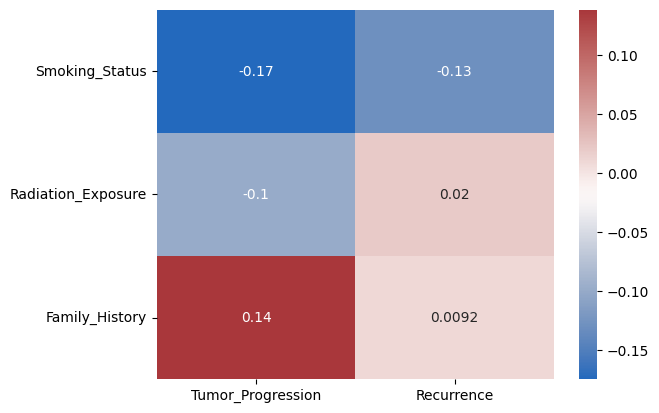

In [27]:
# smoking, radiation exp, family hist, gen risk vs 'Tumor_Progression','Recurrence' -  heat map
corr_matrix = dfmerge[["Smoking_Status", "Radiation_Exposure", "Family_History", "Tumor_Progression", "Recurrence"]].corr()
sns.heatmap(corr_matrix.loc[["Smoking_Status", "Radiation_Exposure", "Family_History"], ["Tumor_Progression","Recurrence"]], annot=True, cmap = "vlag")

In [28]:
#t-test
#family history and survival_months - no
fam_his = dfmerge[dfmerge["Family_History"] == 1]["Survival_Months"]
no_fam_his = dfmerge[dfmerge["Family_History"] == 0]["Survival_Months"]

_, p_value = stats.ttest_ind(fam_his, no_fam_his, equal_var=False)
print(p_value)

#genetic risk and survival_months - no
low_genrisk = dfmerge[dfmerge["Genetic_Risk"] == 0]["Survival_Months"].values
med_genrisk = dfmerge[dfmerge["Genetic_Risk"] == 1]["Survival_Months"].values
high_genrisk = dfmerge[dfmerge["Genetic_Risk"] == 2]["Survival_Months"].values
#test of homogenity (close enough std)
_, p_value2 = stats.levene(low_genrisk, med_genrisk, high_genrisk)
print(p_value2)

f_stat, p_anova = stats.f_oneway(low_genrisk, med_genrisk, high_genrisk)
print(p_anova)

h_stat, p_kruskal = stats.kruskal(low_genrisk, med_genrisk, high_genrisk)
print(p_kruskal)

0.748050592769088
0.06429720292966962
0.8922330087999988
0.9202739380074557


In [29]:
dfmerge.columns

Index(['Patient_ID', 'Age', 'Gender', 'Surgery_Performed', 'Chemotherapy',
       'Radiation_Therapy', 'Survival_Months', 'Tumor_Progression',
       'Recurrence', 'Outcome_Status', 'Early_Detection_Label',
       'Treatment_Response', 'Tumor_Type', 'Tumor_Size_mm', 'Tumor_Location',
       'Tumor_Grade', 'Headache', 'Seizures', 'Vision_Problems', 'Nausea',
       'Cognitive_Changes', 'Edema_Presence', 'Family_History',
       'Smoking_Status', 'Radiation_Exposure', 'Genetic_Risk'],
      dtype='object')

In [30]:
# family history vs outcome-status
twtable = pd.crosstab(dfmerge["Family_History"], dfmerge["Outcome_Status"])
_, p_chi, _, _ = stats.chi2_contingency(twtable)
print(p_chi)


0.7481394520257535


In [31]:
# Genetic_Risk vs otucome
twtable = pd.crosstab(dfmerge["Genetic_Risk"], dfmerge["Outcome_Status"])
_, p_chi, _, _ = stats.chi2_contingency(twtable)
print(p_chi)

0.9759448108753117
